In [1]:
import wfdb
import matplotlib.pyplot as plt

record_name = "example_data\ARR_01"

#load sig
record = wfdb.rdrecord(record_name=record_name)

<>:4: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:4: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\sumaiya.salekin.BRACU\AppData\Local\Temp\ipykernel_3024\3074549347.py:4: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  record_name = "example_data\ARR_01"


In [2]:
record.__dict__

{'record_name': 'ARR_01',
 'n_sig': 6,
 'fs': 1000,
 'counter_freq': None,
 'base_counter': None,
 'sig_len': 600052,
 'base_time': None,
 'base_date': None,
 'comments': [],
 'sig_name': ['ECG',
  'Abdomen_1',
  'Abdomen_2',
  'Abdomen_3',
  'Abdomen_4',
  'Abdomen_5'],
 'p_signal': array([[-0.04075297,  0.39325457, -0.28950284,  0.2495    , -0.1919966 ,
          0.79126119],
        [-0.07248314,  0.57825153, -0.41200488,  0.3582465 , -0.28699883,
          1.11199815],
        [-0.0757539 ,  0.67874992, -0.47874696,  0.41499829, -0.34324471,
          1.27875968],
        ...,
        [ 0.        ,  0.01075318,  0.11950472,  0.23249712,  0.08575296,
          0.03623965],
        [ 0.        ,  0.02499871,  0.21624432,  0.42874984,  0.16199794,
          0.09075927],
        [ 0.        ,  0.03575189,  0.28950284,  0.57624586,  0.21949861,
          0.13126096]], shape=(600052, 6)),
 'd_signal': None,
 'e_p_signal': None,
 'e_d_signal': None,
 'file_name': ['ARR_01.dat',
  'ARR_01.

# implementing the RLS filter

In [3]:
import numpy as np
from filters import RLS

In [4]:
#filter tap specification: 8 to 32 taps

L = 16
delta = 1e3
lamda = 1

#weight initialization
w0 = np.zeros(L)
w0_col = w0.reshape(L, 1)

#filter initialization
rls = RLS(delta=delta, w0=w0_col)

In [5]:
def get_u(chest, n, L):
    return chest[n-L+1 : n+1][::-1]

In [6]:
abd = record.p_signal[:, 1] #1st abdominal sig
chest = record.p_signal[:, 0] #chest abdominal sig

output = []

for n in range(L, len(chest)):
    u = get_u(chest, n, L) #took the past L values from n
    u = u.reshape(L, 1)
    d = abd[n]

    rls.weight_update(measurement_d=d, u=u, lamda=lamda)

    #estimated weights
    w_opt = rls.w_estimates[-1] #taking  the last element with -1; the last time step

    y = np.matmul(u.T, w_opt)

    #the estimated fECG
    e = d - y
    output.append(e)


# Evaluation

In [18]:
def compute_SIR(fetal_signal, abdominal_signal):
    """
    Compute Signal-to-Interference Ratio (SIR) in dB.

    fetal_signal: estimated fECG from RLS (1D array)
    abdominal_signal: original abdominal channel used (1D array, same length as fetal_signal)
    """
    residual_mECG = abdominal_signal - fetal_signal

    power_fetal = np.sum(fetal_signal ** 2)
    power_residual = np.sum(residual_mECG ** 2)

    SIR_dB = 10 * np.log10(power_fetal / power_residual)
    return SIR_dB

# Example usage:
SIR = compute_SIR(output, abd[L:])
print(f"SIR = {SIR:.2f} dB")

SIR = 0.77 dB


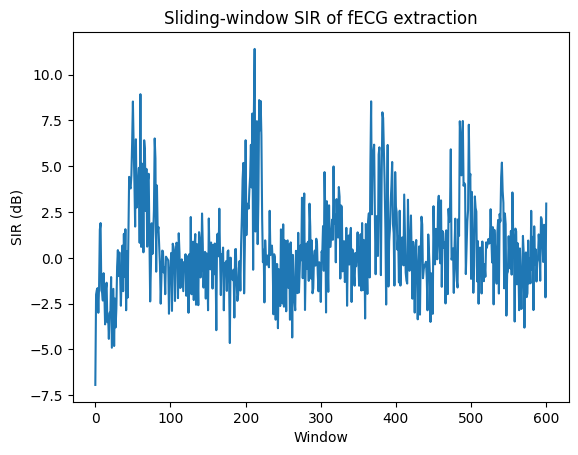

In [19]:
window = 1000  # samples (~1 sec if fs=1kHz)
SIR_windows = []

for start in range(0, len(output), window):
    end = min(start + window, len(output))
    SIR_windows.append(compute_SIR(output[start:end], abd[L+start:L+end]))


plt.plot(SIR_windows)
plt.xlabel('Window')
plt.ylabel('SIR (dB)')
plt.title('Sliding-window SIR of fECG extraction')
plt.show()

# Plots

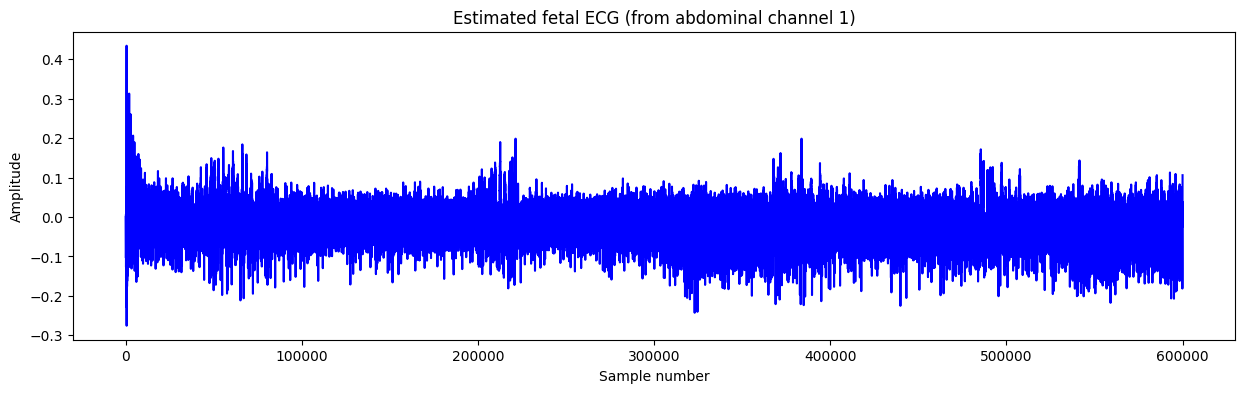

In [7]:
output = np.array(output).flatten()  # make it 1D for plotting

plt.figure(figsize=(15,4))
plt.plot(output, color='blue')
plt.title('Estimated fetal ECG (from abdominal channel 1)')
plt.xlabel('Sample number')
plt.ylabel('Amplitude')
plt.show()

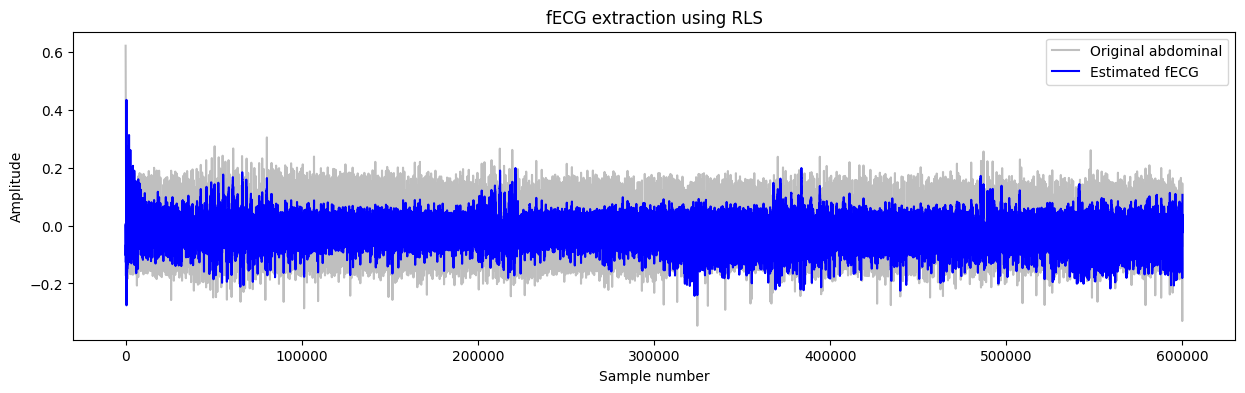

In [8]:
plt.figure(figsize=(15,4))
plt.plot(abd[L:], color='gray', alpha=0.5, label='Original abdominal')
plt.plot(output, color='blue', label='Estimated fECG')
plt.title('fECG extraction using RLS')
plt.xlabel('Sample number')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

In [10]:
fs = record.fs

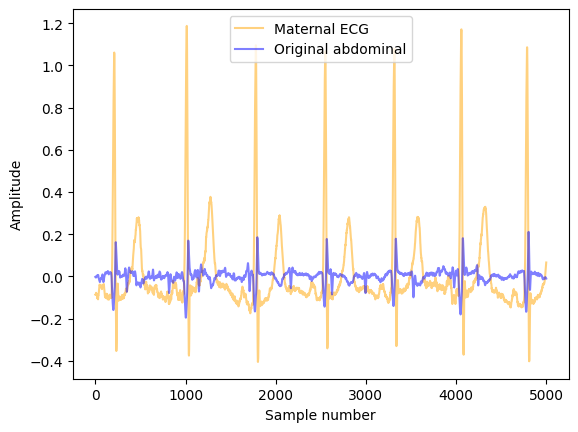

In [16]:
plt.plot(chest[L+start:L+end], color='orange', alpha=0.5, label='Maternal ECG')

plt.plot(abd[L+start:L+end], color='blue', alpha=0.5, label='Original abdominal')

plt.xlabel('Sample number')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

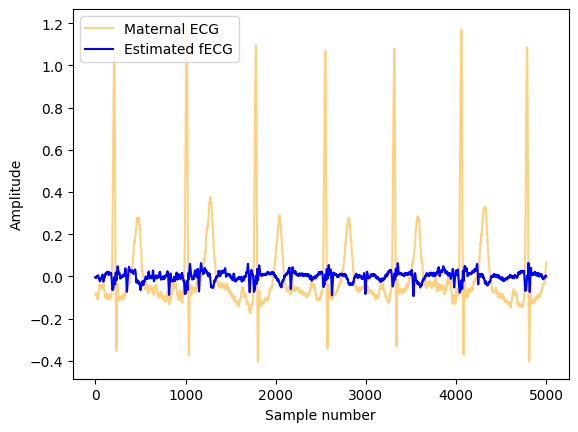

In [17]:
plt.plot(chest[L+start:L+end], color='orange', alpha=0.5, label='Maternal ECG')
plt.plot(output[start:end], color='blue', label='Estimated fECG')

plt.xlabel('Sample number')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

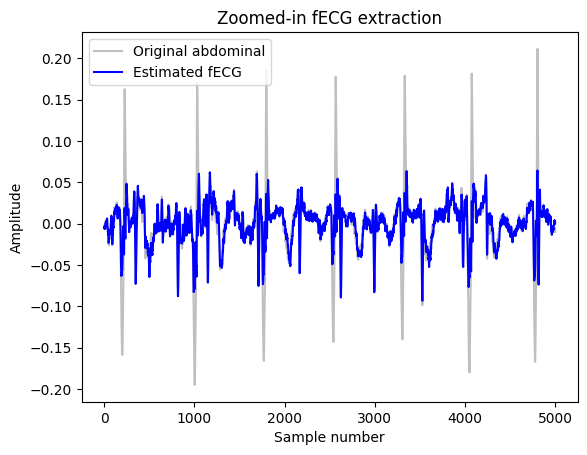

In [13]:
t = 125
start = 120*fs
end = fs*t


plt.plot(abd[L+start:L+end], color='gray', alpha=0.5, label='Original abdominal')
plt.plot(output[start:end], color='blue', label='Estimated fECG')
plt.title('Zoomed-in fECG extraction')
plt.xlabel('Sample number')
plt.ylabel('Amplitude')
plt.legend()
plt.show()